# Análisis y Clasificación de Denuncias de Defensa del Consumidor

En este proyecto se analiza un dataset real de **33,052 denuncias** de consumidores registradas en 2019 y 2020.

El objetivo es **predecir el motivo de una denuncia** según el rubro de la empresa, el mes y la comuna aplicando Machine Learning. Este tipo de modelo permite anticipar problemas frecuentes antes de que escalen.

**Herramientas utilizadas:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('denuncias-defensa-del-consumidor.csv.xlsx')
print('Filas:', len(df))
print(df.head())


Filas: 33052
   DenunciaID      Fecha_Creacion  Comuna  \
0        1999 2019-01-02 11:07:51      11   
1        2000 2019-01-02 11:10:31      11   
2        2001 2019-01-02 11:31:03      11   
3        2002 2019-01-02 12:19:49      11   
4        2003 2019-01-02 15:02:31      11   

                                     Motivo_Denuncia  \
0  Garantia de Bienes. Art 11  Ley 24.240 - Falta...   
1             Falta de cumplimento garantia posventa   
2                Practicas Abusivas - Venta Enganosa   
3  Garantia de Bienes. Art 11  Ley 24.240 - Repar...   
4  Garantia de Bienes. Art 11  Ley 24.240 - Repar...   

                                               Rubro  
0       ELECTRODOMESTICOS Y ARTEFACTOS PARA EL HOGAR  
1       ELECTRODOMESTICOS Y ARTEFACTOS PARA EL HOGAR  
2  SERVICIOS FINANCIEROS (TARJETAS DE CREDITO, BA...  
3       ELECTRODOMESTICOS Y ARTEFACTOS PARA EL HOGAR  
4       ELECTRODOMESTICOS Y ARTEFACTOS PARA EL HOGAR  


## 1. Exploración de Datos (EDA)
Antes de aplicar cualquier modelo, es fundamental entender los datos.
Analizamos qué rubros concentran la mayor cantidad de denuncias
para identificar los sectores más problemáticos para los consumidores.

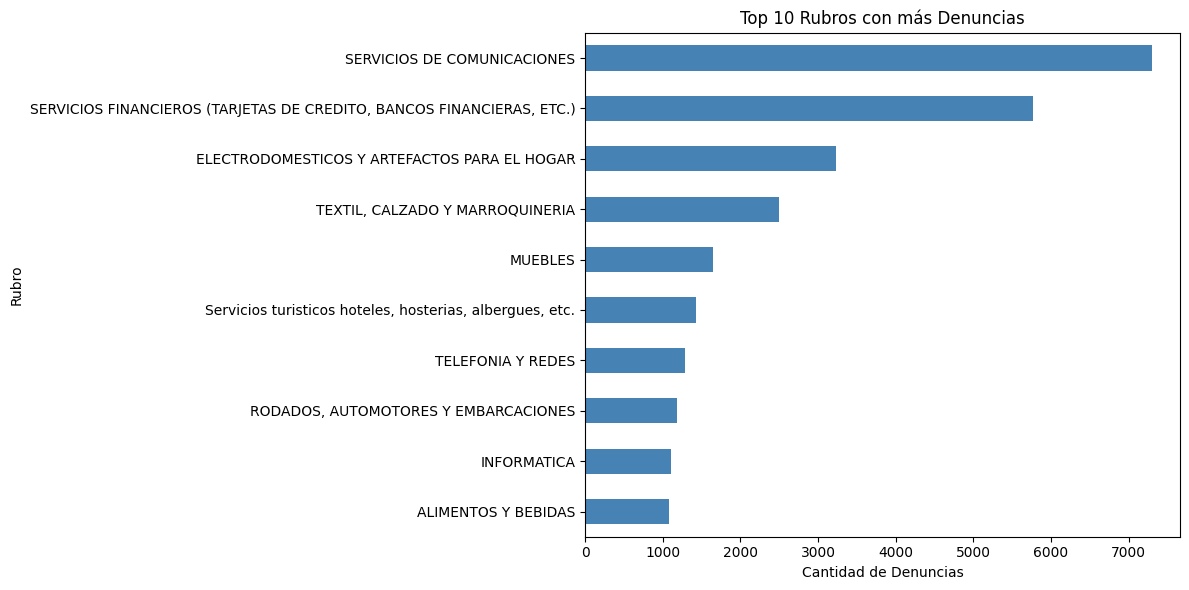

In [ ]:
plt.figure(figsize=(12,6))
df['Rubro'].value_counts().head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Rubros con más Denuncias')
plt.xlabel('Cantidad de Denuncias')
plt.tight_layout()
plt.show()

## 2. Evolución Temporal de las Denuncias
Visualizamos cómo evolucionaron las denuncias mes a mes durante 2019 y 2020.
Esto permite detectar tendencias o picos inusuales que podrían estar
relacionados con eventos económicos o sociales del período.

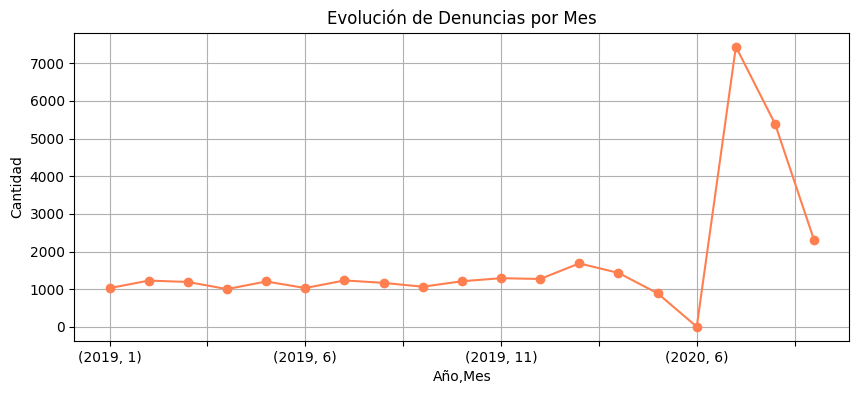

In [ ]:
df['Año'] = df['Fecha_Creacion'].dt.year
df['Mes'] = df['Fecha_Creacion'].dt.month

plt.figure(figsize=(10,4))
df.groupby(['Año','Mes']).size().plot(kind='line', marker='o', color='coral')
plt.title('Evolución de Denuncias por Mes')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()

## 3. Modelo de Machine Learning — Random Forest

Para predecir el motivo de una denuncia se utiliza el algoritmo **Random Forest**,
un modelo de ensamble que combina múltiples árboles de decisión para lograr
predicciones más precisas y robustas.

**Variables de entrada :**
- Rubro de la empresa
- Mes de la denuncia
- Comuna

**Variable a predecir:**
- Motivo de la denuncia

Primero se convierten las variables de texto a formato numérico
mediante Label Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

le_rubro = LabelEncoder()
le_motivo = LabelEncoder()

df['Rubro_enc'] = le_rubro.fit_transform(df['Rubro'])
df['Motivo_enc'] = le_motivo.fit_transform(df['Motivo_Denuncia'])

X = df[['Rubro_enc', 'Mes', 'Comuna']]
y = df['Motivo_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Modelo entrenado')

Modelo entrenado


## 4. Resultados del Modelo

Evaluamos la precisión del modelo sobre datos que nunca vio durante el entrenamiento
(20% del dataset reservado para prueba).

También analizamos qué variables tienen mayor peso en las predicciones,
lo cual nos da información valiosa sobre qué factores determinan
el tipo de denuncia de un consumidor.

Precisión del modelo: 27.42%


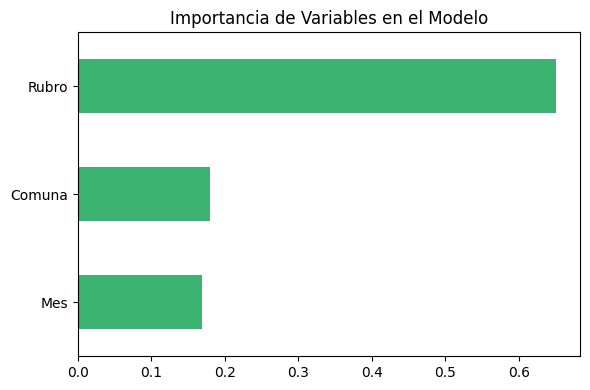

In [ ]:
acc = accuracy_score(y_test, model.predict(X_test))
print(f'Precisión del modelo: {acc:.2%}')

plt.figure(figsize=(6,4))
importancias = pd.Series(model.feature_importances_, index=['Rubro', 'Mes', 'Comuna'])
importancias.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Importancia de Variables en el Modelo')
plt.tight_layout()
plt.show()

## Conclusiones

- El Rubro de la empresa es el factor más determinante para predecir
  el tipo de denuncia que realizará un consumidor.
- Los sectores de Comunicaciones y Servicios Financieros concentran
  la mayor cantidad de reclamos en el período analizado.
- El modelo Random Forest logra identificar patrones reales en más de
  33,000 registros de manera automatizada.
